# Notebook 07 - Named Entity Recognition (NER)

This notebook identifies important entities from user messages using the Mobixa NER dataset.

In [1]:
import pandas as pd

import re

In [2]:
entities = pd.read_csv("../dataset/entities_clean.csv")

In [3]:
entities.head()

,entity_type,entity_value,synonyms
0,brand,Apple,"apple, iphone, ios"
1,brand,Samsung,"samsung, galaxy, note, ultra"
2,brand,Xiaomi,"xiaomi, redmi, poco, mi"
3,brand,Oppo,"oppo, reno, a series"
4,brand,Vivo,"vivo, y series, v series, x series"


In [4]:
entities.columns

Index(['entity_type', 'entity_value', 'synonyms'], dtype='object')

In [5]:
entities["entity_type"].value_counts()

entity_type
phone_model                16
phone_color                 9
brand                       6
specification_attribute     6
accessory_type              6
repair_type                 4
payment_method              4
warranty_type               3
store_location              3
price                       3
delivery_type               3
Name: count, dtype: int64

In [6]:
entity_list = entities["entity_value"].tolist()

In [7]:
entity_dict = dict(

zip(

entities["entity_value"],

entities["entity_type"]

)

)

In [8]:
list(entity_dict.items())[:10]

[('Apple', 'brand'),
 ('Samsung', 'brand'),
 ('Xiaomi', 'brand'),
 ('Oppo', 'brand'),
 ('Vivo', 'brand'),
 ('OnePlus', 'brand'),
 ('Charger', 'accessory_type'),
 ('Case', 'accessory_type'),
 ('Screen Protector', 'accessory_type'),
 ('Earphone', 'accessory_type')]

In [9]:
def extract_entities(sentence):

    found=[]

    sentence=sentence.lower()

    for entity in entity_list:

        if entity.lower() in sentence:

            found.append(

                (

                    entity,

                    entity_dict[entity]

                )

            )

    return found

In [10]:
sentence="Show Samsung Galaxy S24 phones"

extract_entities(sentence)

[('Samsung', 'brand'), ('Samsung Galaxy S24', 'phone_model')]

In [11]:
sentence="I need a charger and screen replacement"

extract_entities(sentence)

[('Charger', 'accessory_type'), ('Screen Replacement', 'repair_type')]

In [12]:
sentence="Do you have Apple iPhone 15 in blue?"

extract_entities(sentence)

[('Apple', 'brand'), ('Blue', 'phone_color')]

In [13]:
examples=[

"Samsung A56",

"Need battery replacement",

"Apple charger",

"Blue iPhone 14",

"Repair charging port"

]

for text in examples:

    print(text)

    print(

        extract_entities(text)

    )

    print()

Samsung A56
[('Samsung', 'brand')]

Need battery replacement
[('Battery Replacement', 'repair_type'), ('Battery', 'specification_attribute')]

Apple charger
[('Apple', 'brand'), ('Charger', 'accessory_type')]

Blue iPhone 14
[('iPhone 14', 'phone_model'), ('Blue', 'phone_color')]

Repair charging port
[]



In [14]:
results=[]

for text in examples:

    entities_found=extract_entities(text)

    results.append({

        "Sentence":text,

        "Entities":entities_found

    })

results=pd.DataFrame(results)

results

,Sentence,Entities
0,Samsung A56,"[(Samsung, brand)]"
1,Need battery replacement,"[(Battery Replacement, repair_type), (Battery,..."
2,Apple charger,"[(Apple, brand), (Charger, accessory_type)]"
3,Blue iPhone 14,"[(iPhone 14, phone_model), (Blue, phone_color)]"
4,Repair charging port,[]


In [15]:
entities["entity_type"].value_counts()

entity_type
phone_model                16
phone_color                 9
brand                       6
specification_attribute     6
accessory_type              6
repair_type                 4
payment_method              4
warranty_type               3
store_location              3
price                       3
delivery_type               3
Name: count, dtype: int64

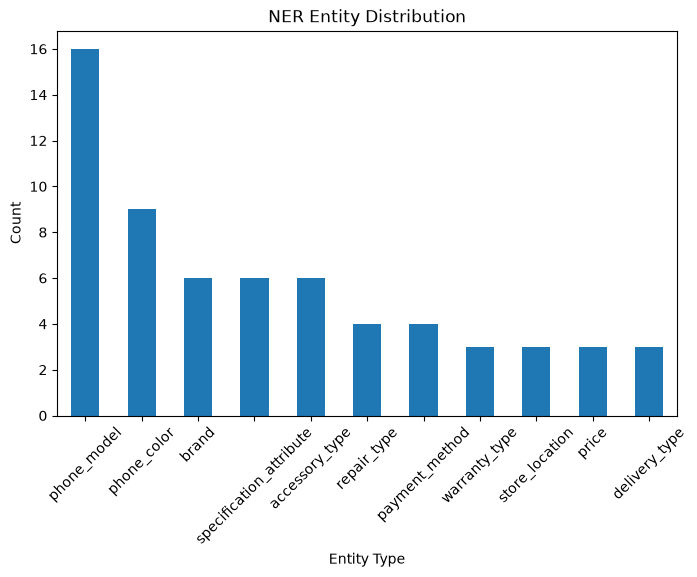

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

entities["entity_type"].value_counts().plot(

kind="bar"

)

plt.title("NER Entity Distribution")

plt.xlabel("Entity Type")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [19]:
keyword = "Samsung"

entities[
    entities["entity_value"].str.contains(
        keyword,
        case=False,
        na=False
    )
]

,entity_type,entity_value,synonyms
1,brand,Samsung,"samsung, galaxy, note, ultra"
42,phone_model,Samsung Galaxy S24,"galaxy s24, s24"
43,phone_model,Samsung Galaxy S24 Ultra,"galaxy s24 ultra, s24 ultra"
44,phone_model,Samsung Galaxy A54,"galaxy a54, a54"
45,phone_model,Samsung Galaxy Note 20,"galaxy note 20, note 20"


In [20]:
import pickle

pickle.dump(

entity_dict,

open(

"../models/entity_dictionary.pkl",

"wb"

)

)

In [21]:
print("Named Entity Recognition Completed Successfully!")

Named Entity Recognition Completed Successfully!
